# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  7588k      0 --:--:--  0:01:58 --:--:-- 6850k


In [3]:
#!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [4]:
#!gunzip SUSY.csv.gz

In [6]:
ls -lh

total 4685592
-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 4685592
-rw-------@ 1 afarbin  staff   389K Mar 20 13:47 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


We see that we have 5 million datapoints.

In [8]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [9]:
!head -500000 SUSY.csv > SUSY-small.csv

In [10]:
ls -lh

total 5152448
-rw-------@ 1 afarbin  staff   389K Mar 20 13:49 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   8.0M Mar 20 12:18 Lab.7.pdf
-rw-r--r--  1 afarbin  staff   228M Mar 20 13:50 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 20 11:36 SUSY.csv


In [11]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [12]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [13]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [14]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [15]:
FeatureNames

['axial_MET',
 'MT2',
 'M_Delta_R',
 'M_R',
 'S_R',
 'M_TR_2',
 'dPhi_r_b',
 'R',
 'MET_rel',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [17]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/iostream.py", line 105, in _handle_subscription
    event_type = frame[0]
                 ~~~~~^^^
IndexError: index out of range
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
    ~~~~~~~~~~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
    ~~~~~~~~~~~~~~~~~~^

You can see the data in Jupyter by just evaluateing the dataframe:

In [11]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [11]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


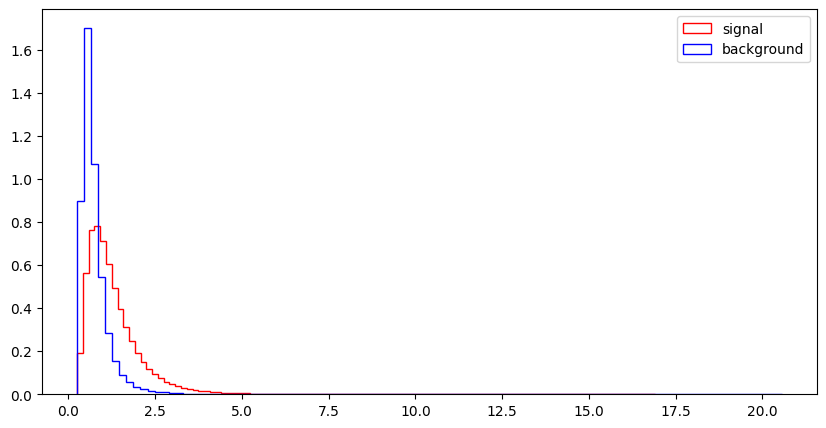

l_1_eta


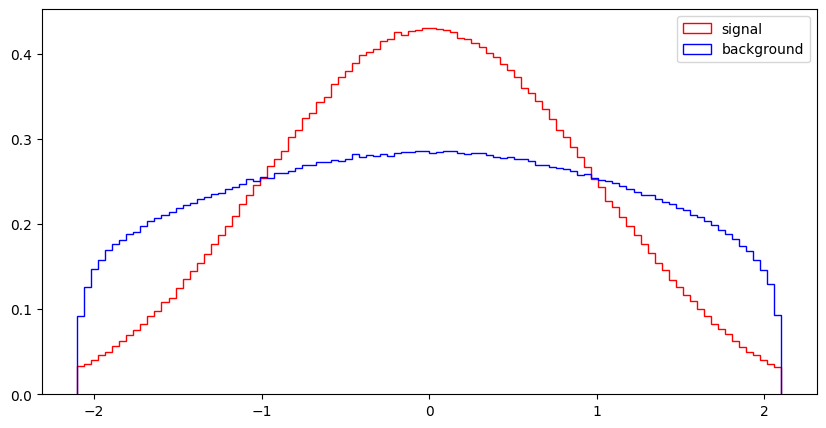

l_1_phi


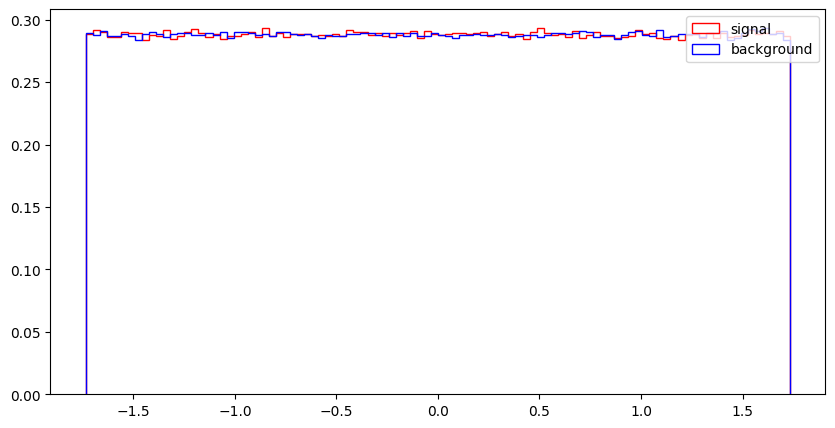

l_2_pT


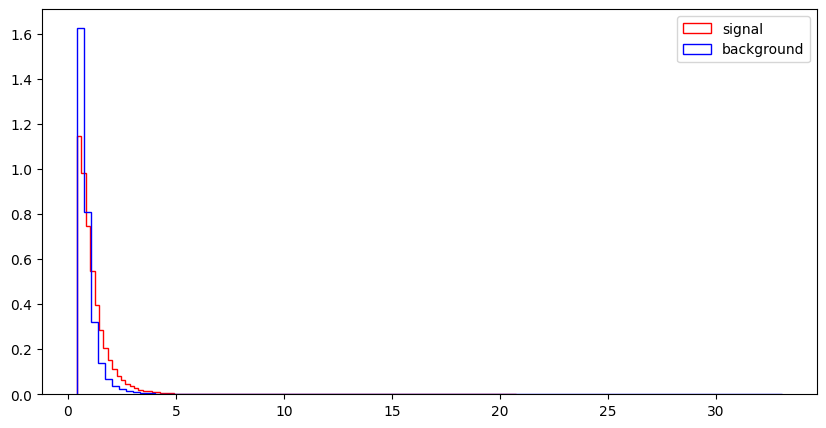

l_2_eta


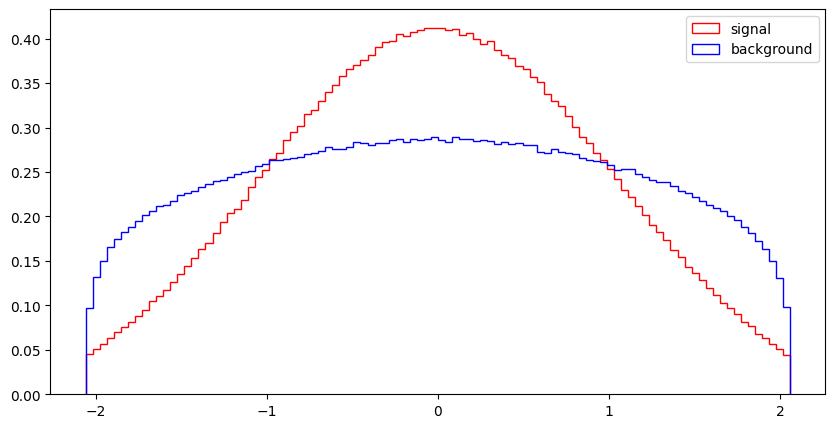

l_2_phi


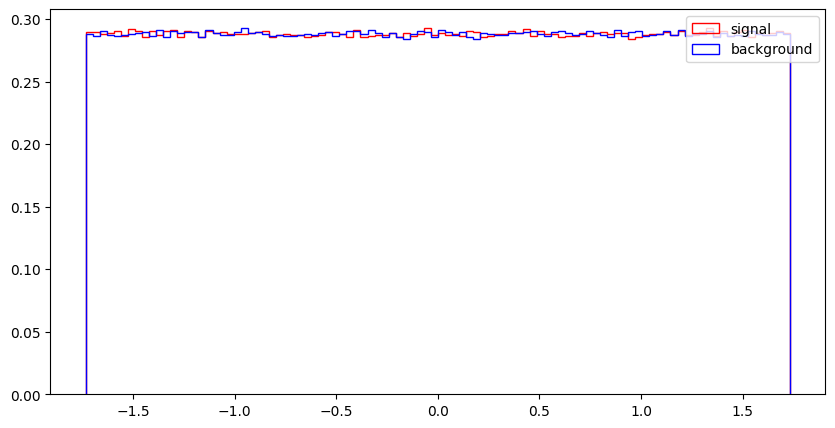

MET


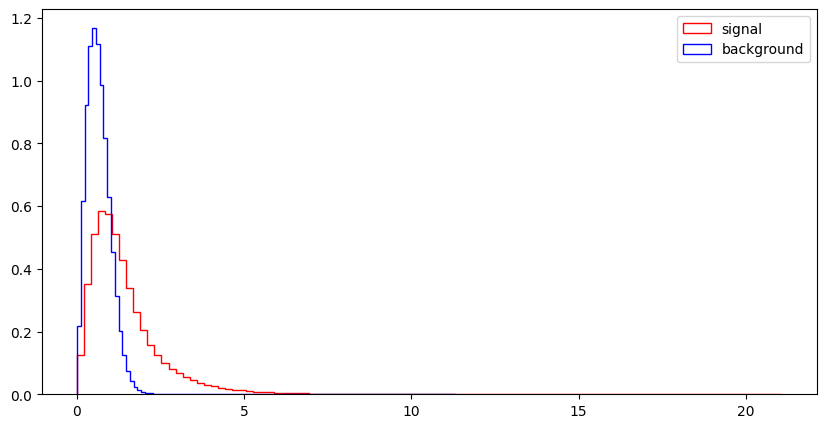

MET_phi


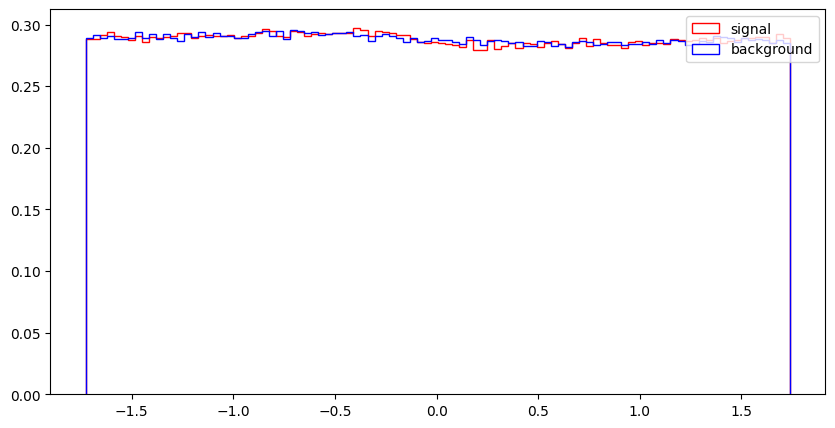

MET_rel


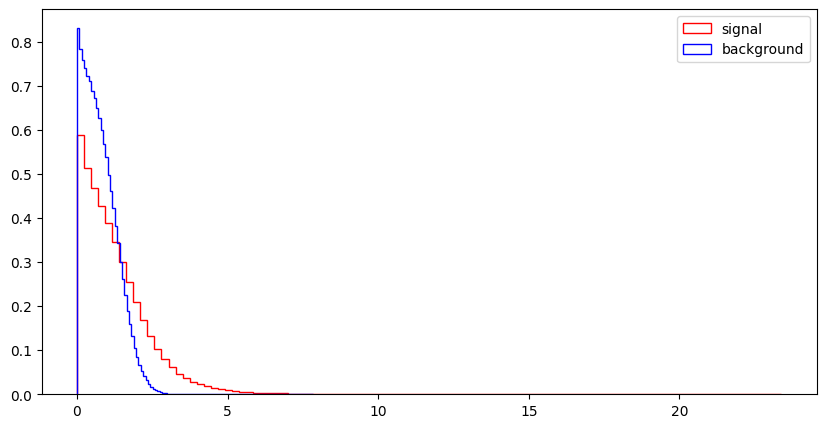

axial_MET


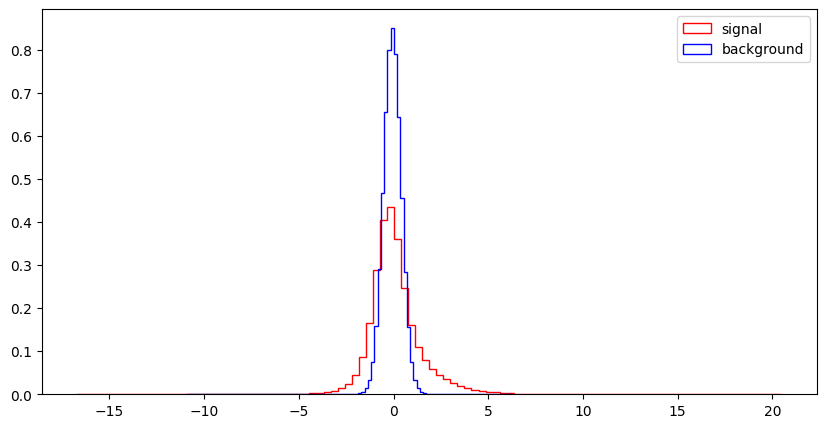

M_R


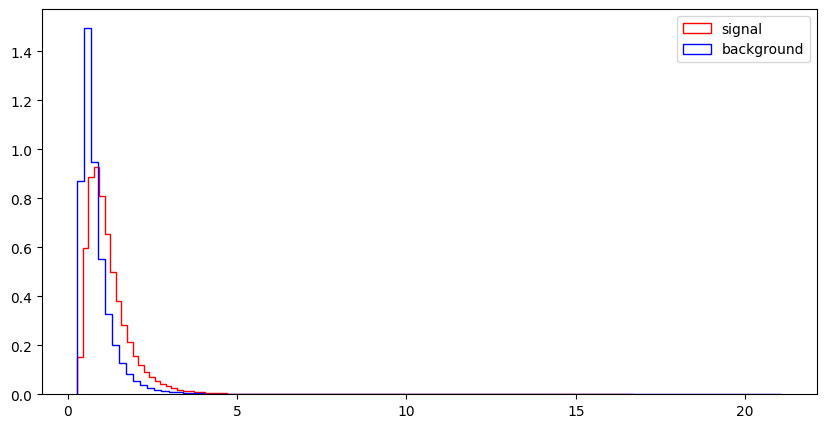

M_TR_2


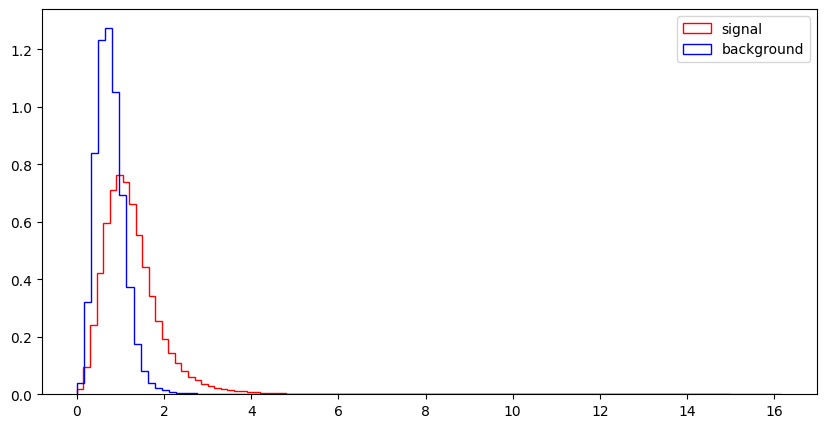

R


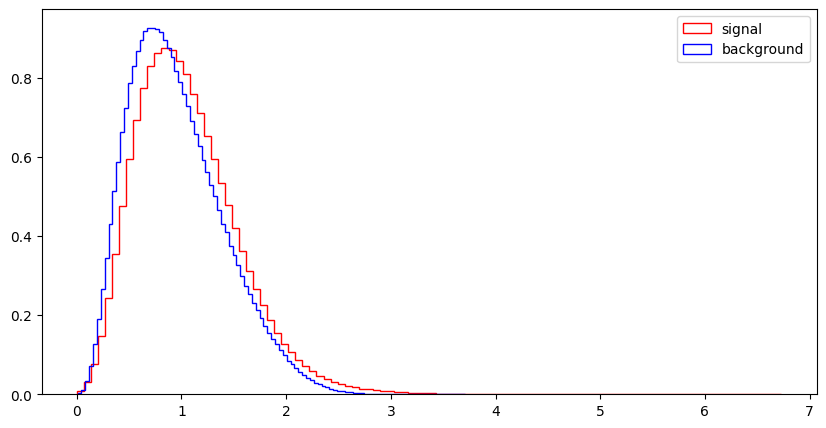

MT2


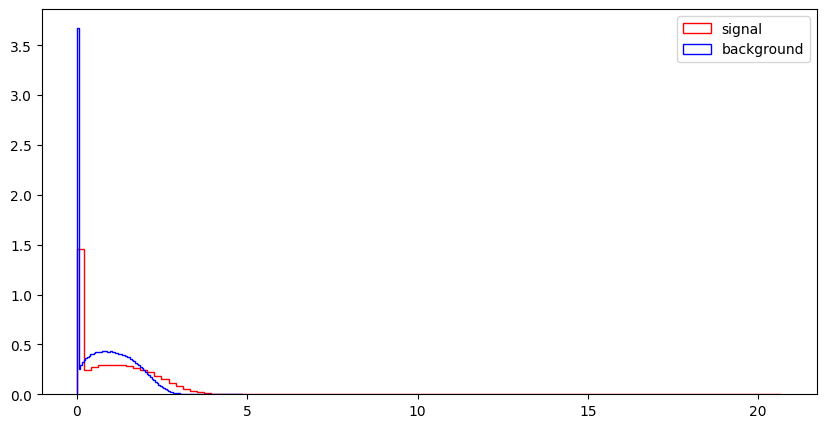

S_R


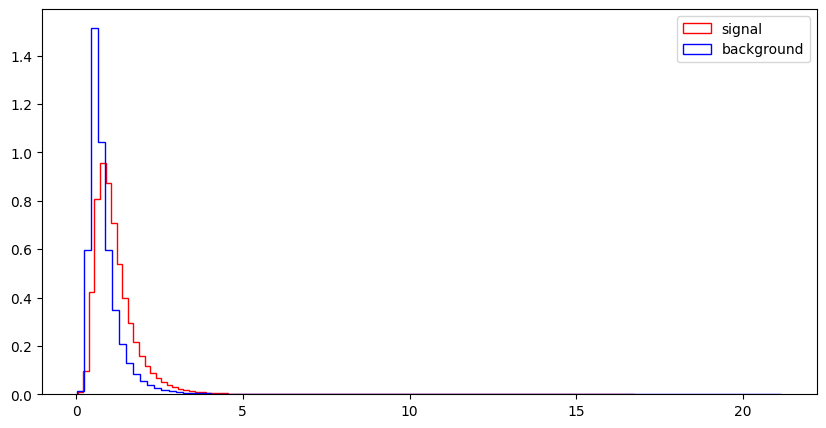

M_Delta_R


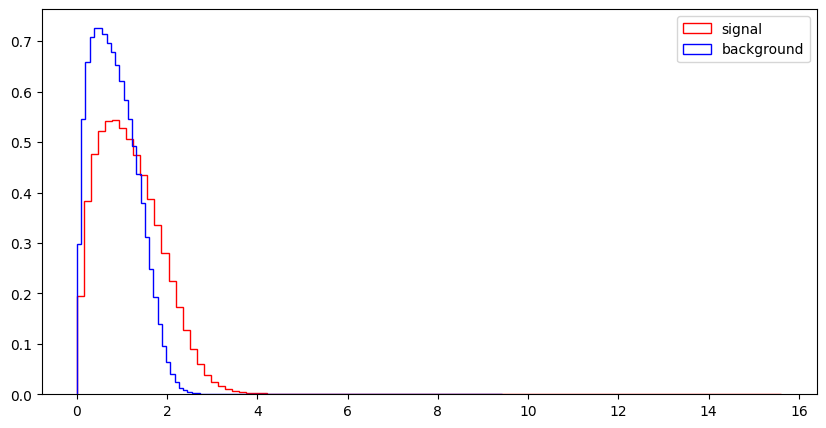

dPhi_r_b


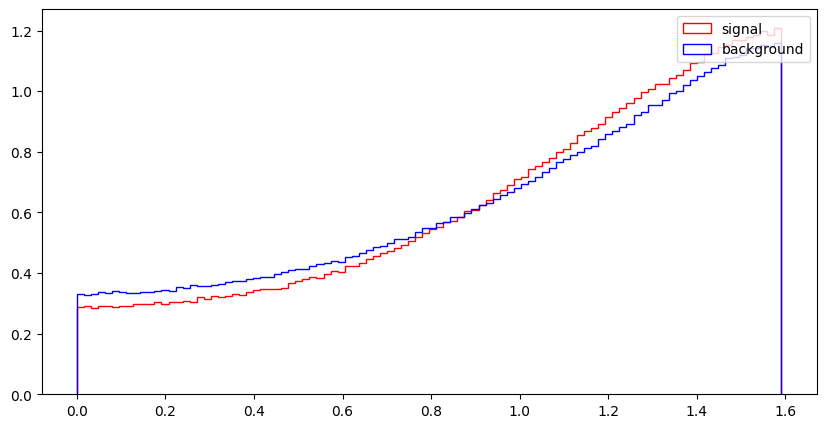

cos_theta_r1


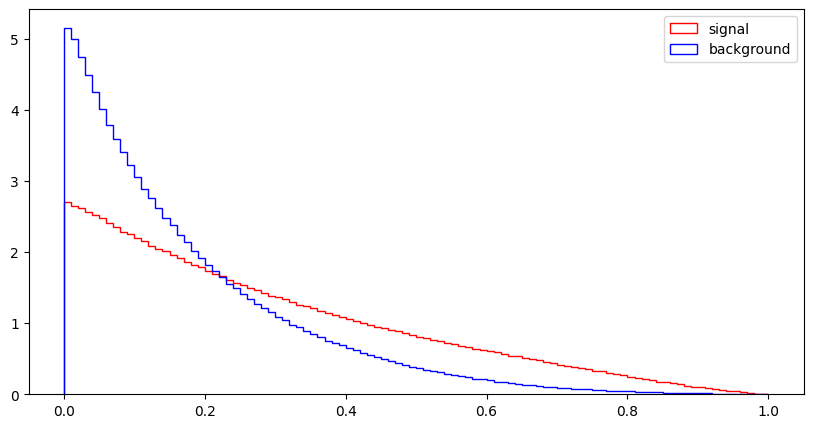

In [13]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

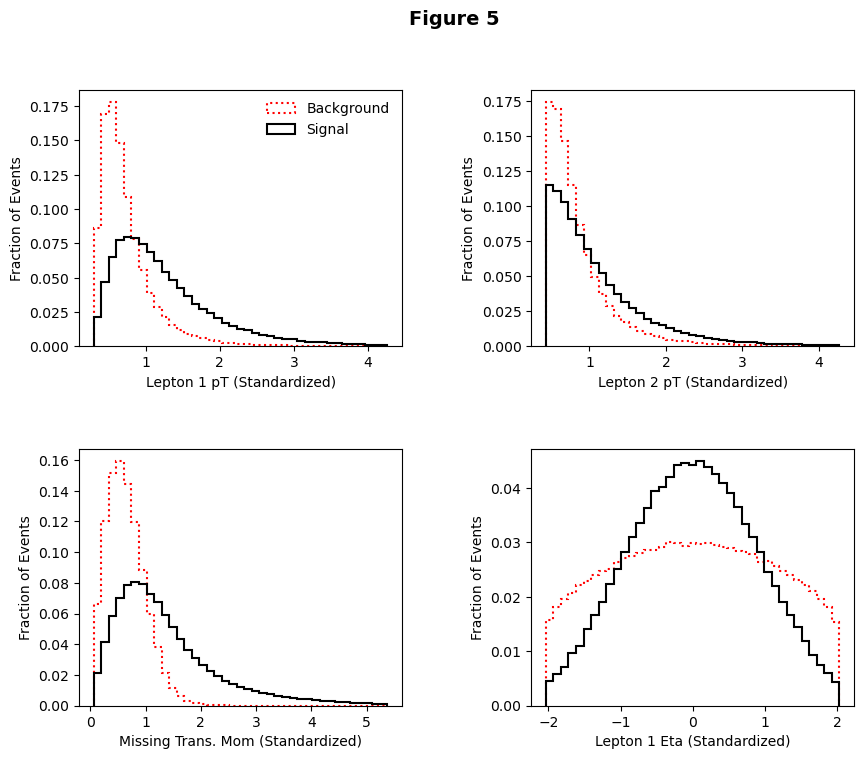

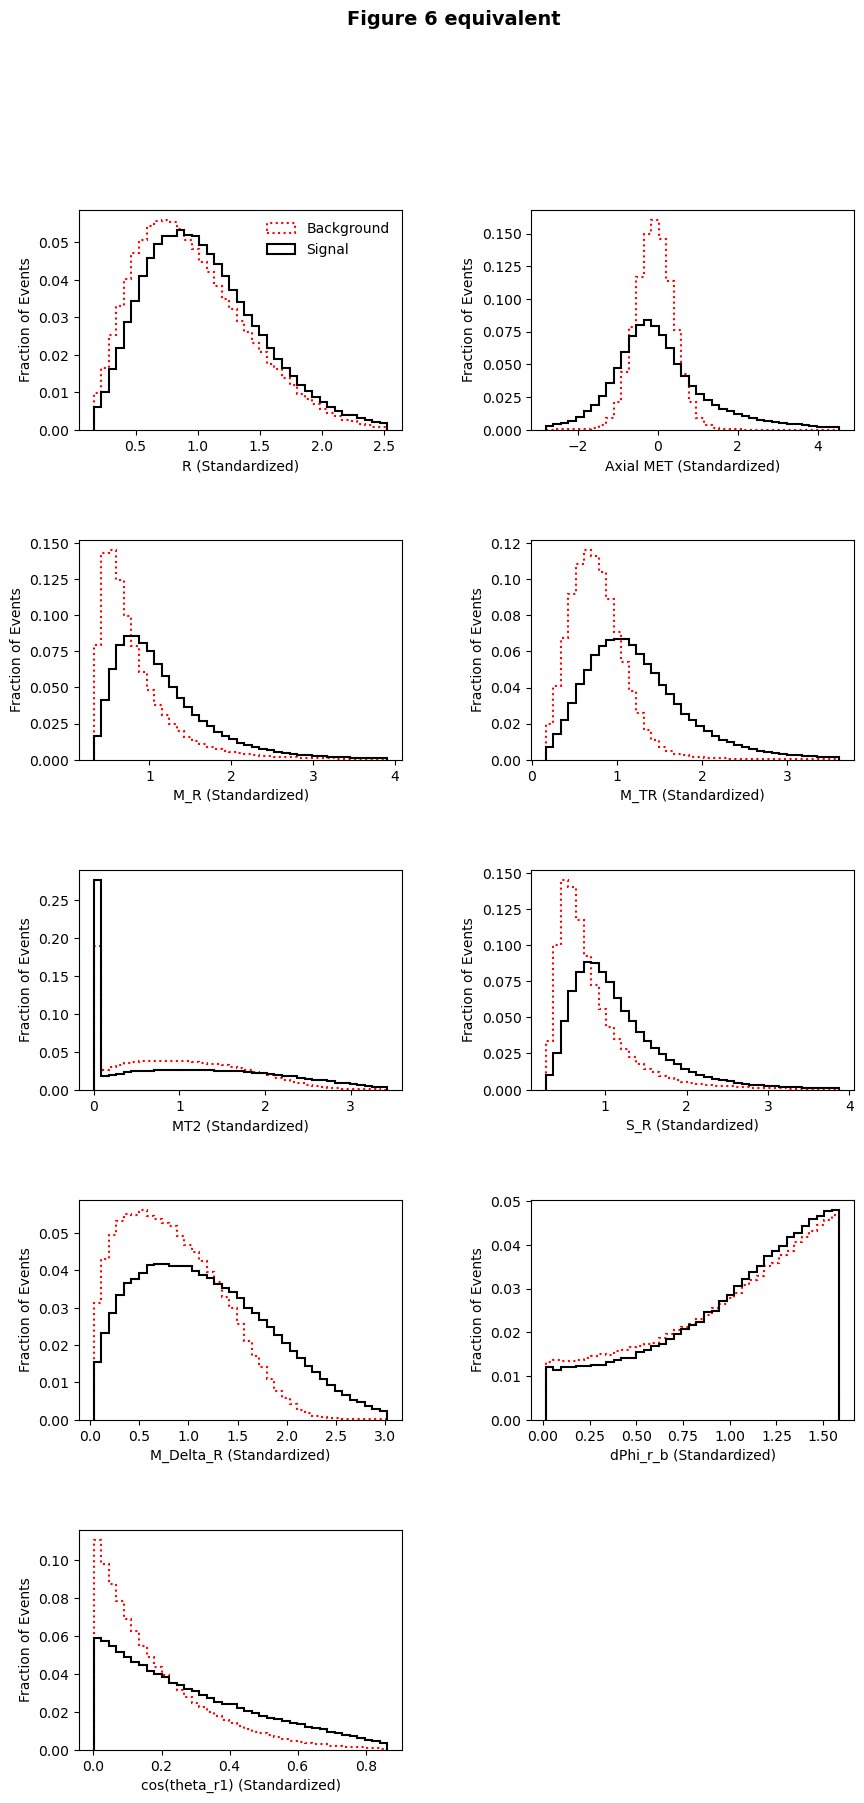

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset

cols = [
    'label', 
    'lepton_1_pT', 'lepton_1_eta', 'lepton_1_phi', 
    'lepton_2_pT', 'lepton_2_eta', 'lepton_2_phi', 
    'MET', 'MET_phi', 
    'MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 
    'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'
]

df = pd.read_csv('SUSY-small.csv', header=None, names=cols)

# Separate signal and background 
signal = df[df['label'] == 1.0]
background = df[df['label'] == 0.0]

# Helper function to plot histograms correctly
def plot_feature_hist(ax, feature, xlabel):
    sig_data = signal[feature].values
    bkg_data = background[feature].values
    
    if len(sig_data) == 0 or len(bkg_data) == 0:
        ax.text(0.5, 0.5, 'No Data Found', ha='center')
        return

    # capturing the 0.5th to 99.5th percentiles to avoid stretching from extreme outliers.
    min_val = max(min(sig_data.min(), bkg_data.min()), np.percentile(df[feature], 0.5))
    max_val = min(max(sig_data.max(), bkg_data.max()), np.percentile(df[feature], 99.5))
    bins = np.linspace(min_val, max_val, 40)
    
    # Calculate weights to show actual "Fraction of Events" instead of density
    sig_weights = np.ones_like(sig_data) / len(sig_data)
    bkg_weights = np.ones_like(bkg_data) / len(bkg_data)
    
    # Plot background 
    ax.hist(bkg_data, bins=bins, weights=bkg_weights, histtype='step', 
            color='red', linestyle='dotted', linewidth=1.5, label='Background')
    
    # Plot signal 
    ax.hist(sig_data, bins=bins, weights=sig_weights, histtype='step', 
            color='black', linestyle='solid', linewidth=1.5, label='Signal')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Fraction of Events')
    
    # Ensure y-axis starts at 0 and adds a slight margin at the top
    ax.set_ylim(bottom=0)
    

# Reproducing Figure 5
fig5, axs5 = plt.subplots(2, 2, figsize=(10, 8))
fig5.subplots_adjust(hspace=0.4, wspace=0.4)

low_level_features = [
    ('lepton_1_pT', 'Lepton 1 pT (Standardized)'),
    ('lepton_2_pT', 'Lepton 2 pT (Standardized)'),
    ('MET', 'Missing Trans. Mom (Standardized)'),
    ('lepton_1_eta', 'Lepton 1 Eta (Standardized)')
]

for ax, (feature, xlabel) in zip(axs5.flatten(), low_level_features):
    plot_feature_hist(ax, feature, xlabel)

axs5[0, 0].legend(frameon=False)
fig5.suptitle("Figure 5", fontsize=14, fontweight='bold')
plt.show()

# Reproducing Figure 6 
fig6, axs6 = plt.subplots(5, 2, figsize=(10, 20))
fig6.subplots_adjust(hspace=0.5, wspace=0.4)

high_level_features = [
    ('R', 'R (Standardized)'),
    ('axial_MET', 'Axial MET (Standardized)'),
    ('M_R', 'M_R (Standardized)'),
    ('M_TR_2', 'M_TR (Standardized)'),
    ('MT2', 'MT2 (Standardized)'),
    ('S_R', 'S_R (Standardized)'),
    ('M_Delta_R', 'M_Delta_R (Standardized)'),
    ('dPhi_r_b', 'dPhi_r_b (Standardized)'),
    ('cos_theta_r1', 'cos(theta_r1) (Standardized)')
]

axs_flat = axs6.flatten()
for i, (feature, xlabel) in enumerate(high_level_features):
    plot_feature_hist(axs_flat[i], feature, xlabel)

axs_flat[0].legend(frameon=False)
axs_flat[9].set_visible(False) # Hide the last empty subplot

fig6.suptitle("Figure 6 equivalent", fontsize=14, fontweight='bold')
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

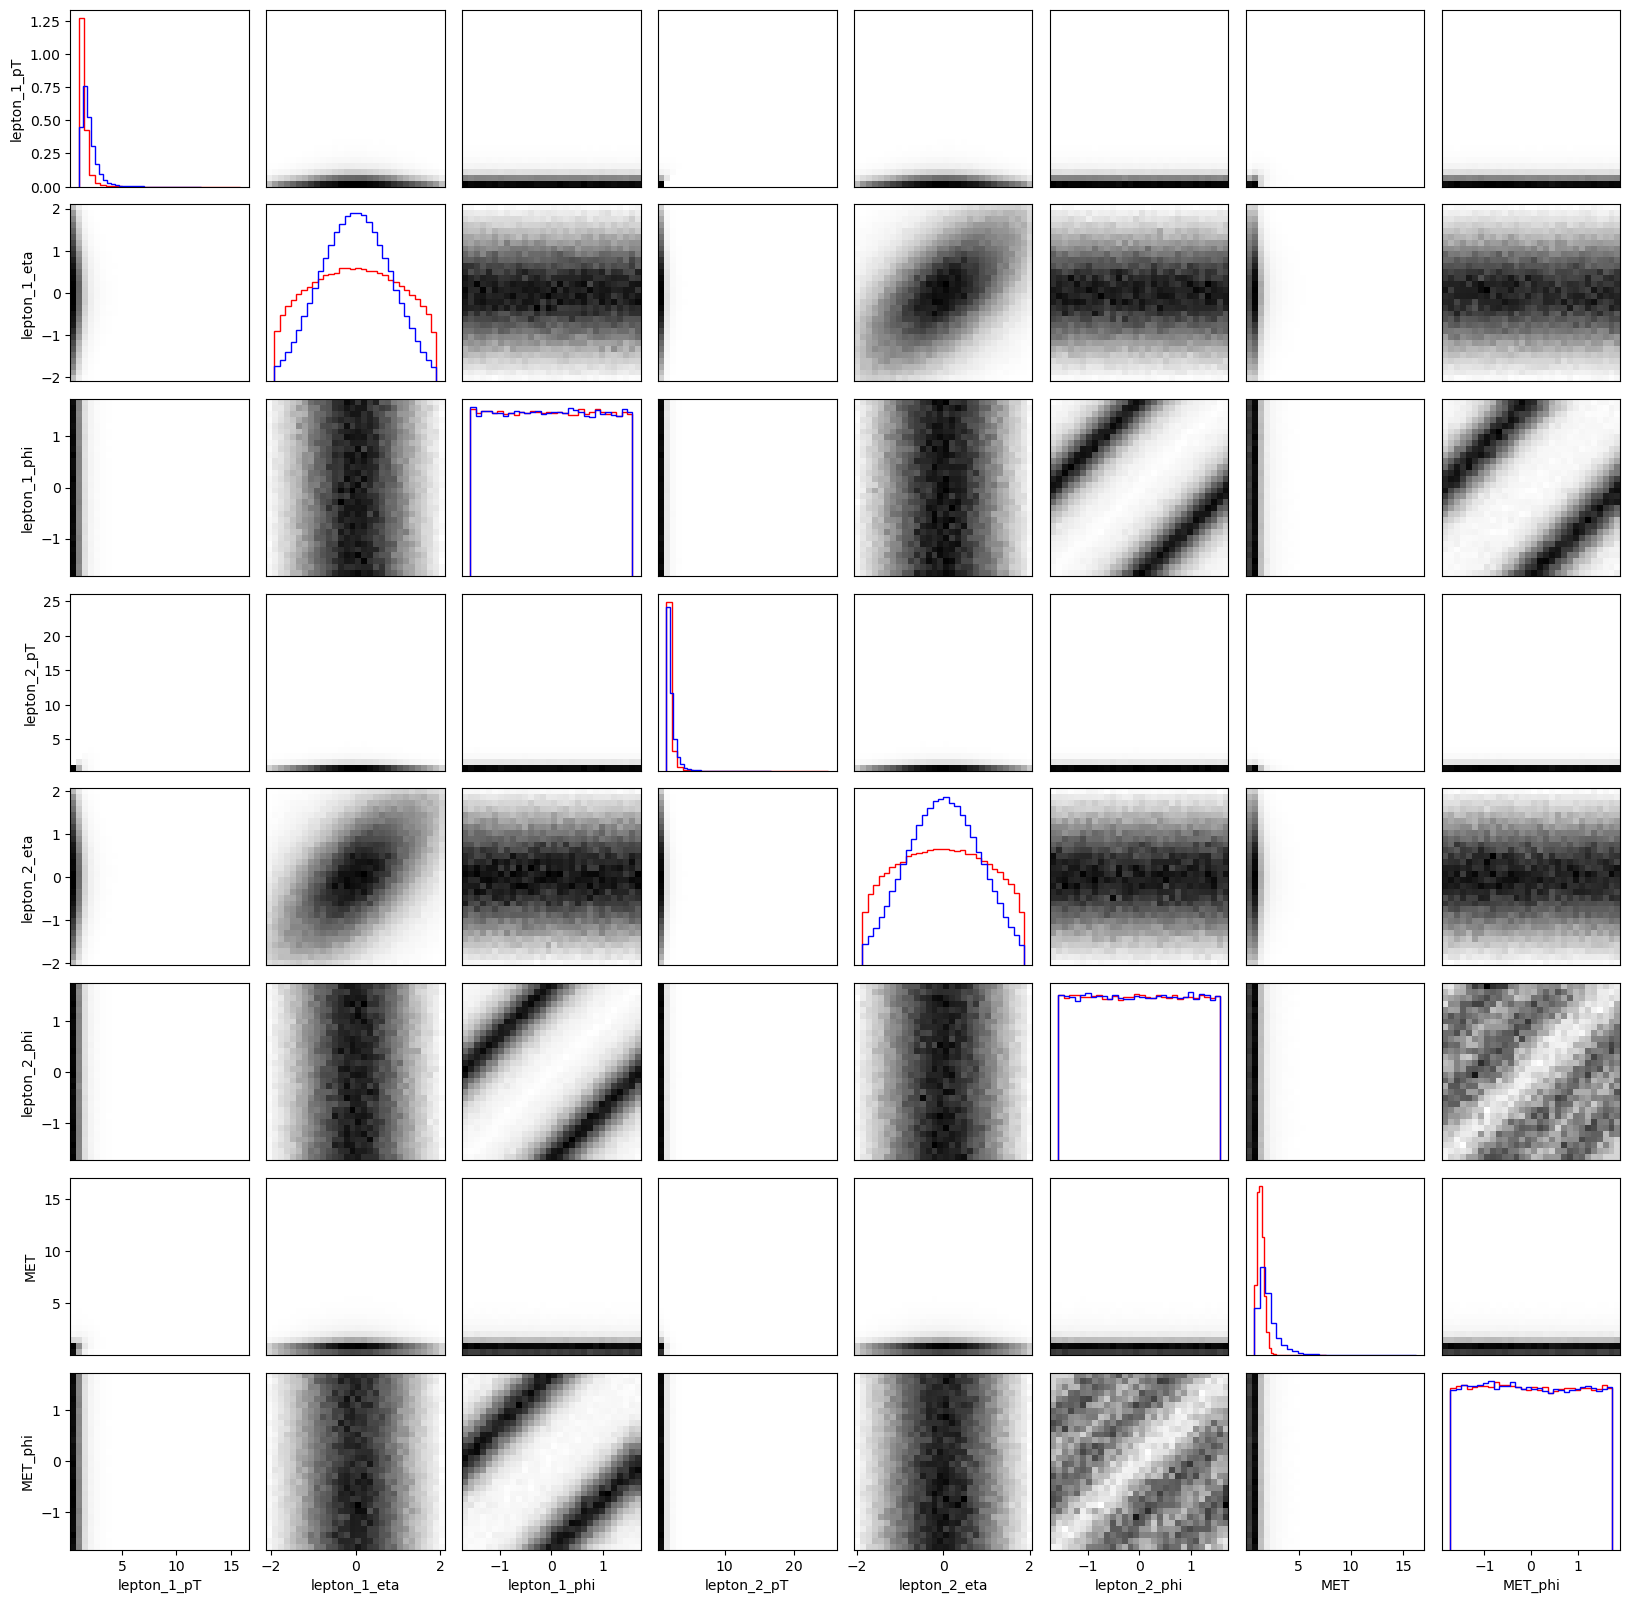

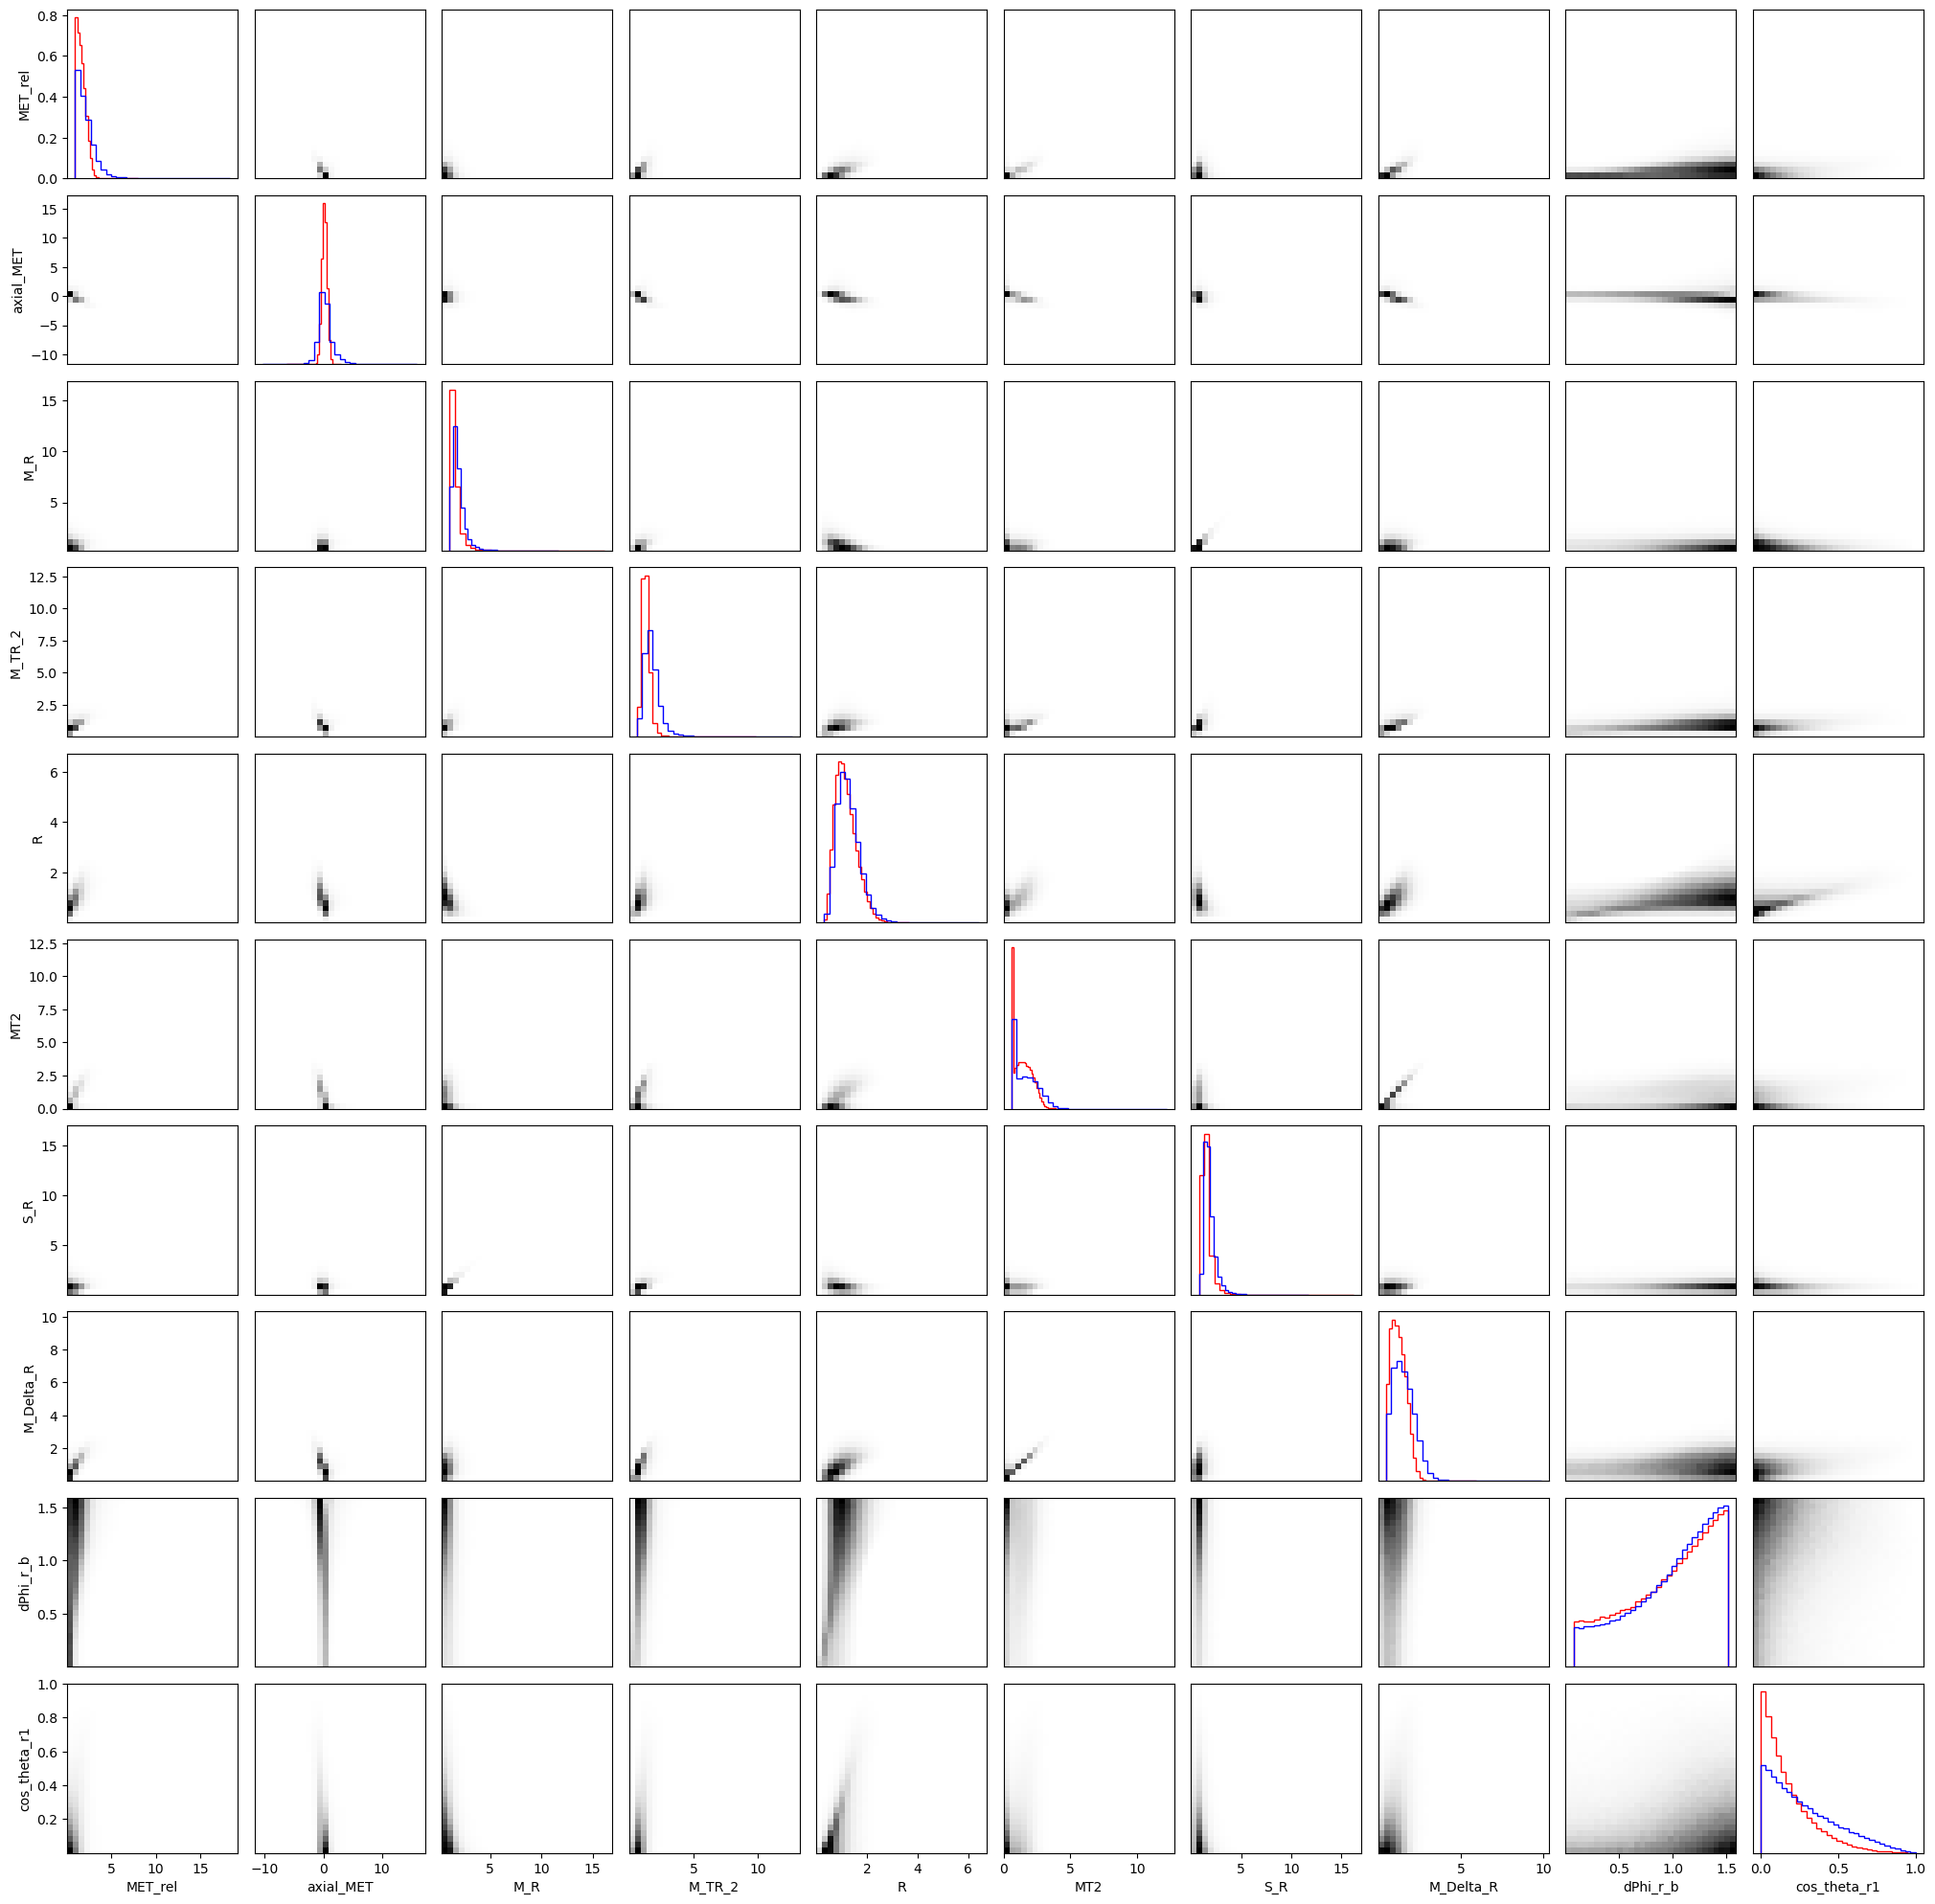

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
cols = [
    'label', 
    'lepton_1_pT', 'lepton_1_eta', 'lepton_1_phi', 
    'lepton_2_pT', 'lepton_2_eta', 'lepton_2_phi', 
    'MET', 'MET_phi', 
    'MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 
    'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'
]

df = pd.read_csv('SUSY-small.csv', header=None, names=cols)

# Part A
def pair_plot_naive(df, features, target_col='label'):

    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(n * 2.5, n * 2.5))
    fig.subplots_adjust(wspace=0.1, hspace=0.1)
    
    # Separate the classes
    sig = df[df[target_col] == 1]
    bkg = df[df[target_col] == 0]
    
    for i, feat_y in enumerate(features):
        for j, feat_x in enumerate(features):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: 1D Histograms
                ax.hist(bkg[feat_x], bins=30, histtype='step', color='red', label='Background', density=True)
                ax.hist(sig[feat_x], bins=30, histtype='step', color='blue', label='Signal', density=True)
            else:
                # Off-diagonal: Scatter plot
                ax.scatter(bkg[feat_x], bkg[feat_y], color='red', alpha=0.1, s=1, label='Background')
                ax.scatter(sig[feat_x], sig[feat_y], color='blue', alpha=0.1, s=1, label='Signal')
            
            # Format axes
            if i == n - 1:
                ax.set_xlabel(feat_x)
            else:
                ax.set_xticks([])
                
            if j == 0:
                ax.set_ylabel(feat_y)
            else:
                ax.set_yticks([])
                
    axes[0, 0].legend(loc='upper right', fontsize='small')
    plt.show()


# Part B
def pair_plot_fast(df, features, target_col='label'):

    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(n * 2.5, n * 2.5))
    fig.subplots_adjust(wspace=0.1, hspace=0.1)
    
    sig_mask = (df[target_col] == 1).values
    bkg_mask = (df[target_col] == 0).values
    
    data_sig = {f: df[f].values[sig_mask] for f in features}
    data_bkg = {f: df[f].values[bkg_mask] for f in features}
    
    for i, feat_y in enumerate(features):
        for j, feat_x in enumerate(features):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: 1D Histograms
                ax.hist(data_bkg[feat_x], bins=30, histtype='step', color='red', density=True)
                ax.hist(data_sig[feat_x], bins=30, histtype='step', color='blue', density=True)
            else:
                ax.hist2d(df[feat_x].values, df[feat_y].values, bins=30, cmap='Greys')
                
            if i == n - 1:
                ax.set_xlabel(feat_x)
            else:
                ax.set_xticks([])
                
            if j == 0:
                ax.set_ylabel(feat_y)
            else:
                ax.set_yticks([])
                
    plt.show()

# Define the exact features to plot based on the paper's feature sets
low_level_feats = [
    'lepton_1_pT', 'lepton_1_eta', 'lepton_1_phi', 
    'lepton_2_pT', 'lepton_2_eta', 'lepton_2_phi', 
    'MET', 'MET_phi'
]

high_level_feats = [
    'MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 
    'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'
]

pair_plot_fast(df, low_level_feats)
pair_plot_fast(df, high_level_feats)

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [6]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [21]:
import numpy as np
import tabulate
from IPython.display import HTML, display

# Part D
def display_cov_cor_matrices(df, features, title):

    display(HTML(f"<h2>{title}</h2>"))
    
# Part B

    data_array = df[features].values.T
    
    cov_matrix = np.cov(data_array)
    cor_matrix = np.corrcoef(data_array)
    
# Part B
    cov_table = []
    cor_table = []
    
    for i, row_name in enumerate(features):
        # Format strings to appropriate significant figures 
        # Decimals for correlation, 3 sig figs for covariance
        cov_row = [row_name] + [f"{val:.3g}" for val in cov_matrix[i]]
        cor_row = [row_name] + [f"{val:.3f}" for val in cor_matrix[i]]
        
        cov_table.append(cov_row)
        cor_table.append(cor_row)
        
    # Create headers 
    headers = ["Features"] + features
    
    # Embed the tables into the notebook using HTML and tabulate
    display(HTML("<h3>Covariance Matrix</h3>"))
    display(HTML(tabulate.tabulate(cov_table, tablefmt='html', headers=headers)))
    
    display(HTML("<h3>Correlation Matrix</h3>"))
    display(HTML(tabulate.tabulate(cor_table, tablefmt='html', headers=headers)))
    display(HTML("<hr>")) # Adds a horizontal line for clean separation



low_level_feats = [
    'lepton_1_pT', 'lepton_1_eta', 'lepton_1_phi', 
    'lepton_2_pT', 'lepton_2_eta', 'lepton_2_phi', 
    'MET', 'MET_phi'
]

high_level_feats = [
    'MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 
    'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'
]

all_feats = low_level_feats + high_level_feats

# Low-level features
display_cov_cor_matrices(df, low_level_feats, "Low-Level Features")

# High-level features
display_cov_cor_matrices(df, high_level_feats, "High-Level Features")

# All observables
display_cov_cor_matrices(df, all_feats, "All Observables")

Features,lepton_1_pT,lepton_1_eta,lepton_1_phi,lepton_2_pT,lepton_2_eta,lepton_2_phi,MET,MET_phi
lepton_1_pT,0.467,-0.000397,7.66e-05,0.305,-0.000349,0.000737,0.228,-0.000937
lepton_1_eta,-0.000397,1,-0.000858,-0.000163,0.408,-0.00104,-0.00215,-0.000589
lepton_1_phi,7.66e-05,-0.000858,1,0.00131,0.000251,-0.267,0.000766,-0.185
lepton_2_pT,0.305,-0.000163,0.00131,0.425,-0.000576,0.000156,0.0795,-0.00156
lepton_2_eta,-0.000349,0.408,0.000251,-0.000576,1.01,0.000442,0.000382,-0.000322
lepton_2_phi,0.000737,-0.00104,-0.267,0.000156,0.000442,1,-0.000304,-0.0354
MET,0.228,-0.00215,0.000766,0.0795,0.000382,-0.000304,0.762,-0.00279
MET_phi,-0.000937,-0.000589,-0.185,-0.00156,-0.000322,-0.0354,-0.00279,1


Features,lepton_1_pT,lepton_1_eta,lepton_1_phi,lepton_2_pT,lepton_2_eta,lepton_2_phi,MET,MET_phi
lepton_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
lepton_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
lepton_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
lepton_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
lepton_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
lepton_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1


Features,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,0.79,-0.12,0.0437,0.302,0.249,0.409,0.0823,0.415,0.146,0.0553
axial_MET,-0.12,1.01,0.0171,-0.185,-0.181,-0.461,-0.0414,-0.233,-0.0251,-0.0537
M_R,0.0437,0.0171,0.392,0.21,-0.113,-0.0365,0.38,0.0739,-0.029,-0.0143
M_TR_2,0.302,-0.185,0.21,0.338,0.104,0.189,0.228,0.242,0.0581,0.0517
R,0.249,-0.181,-0.113,0.104,0.222,0.232,-0.0834,0.165,0.0871,0.0582
MT2,0.409,-0.461,-0.0365,0.189,0.232,0.738,-0.011,0.433,0.0209,0.0446
S_R,0.0823,-0.0414,0.38,0.228,-0.0834,-0.011,0.382,0.0958,-0.00346,-0.0104
M_Delta_R,0.415,-0.233,0.0739,0.242,0.165,0.433,0.0958,0.389,0.0422,0.0392
dPhi_r_b,0.146,-0.0251,-0.029,0.0581,0.0871,0.0209,-0.00346,0.0422,0.19,0.00908
cos_theta_r1,0.0553,-0.0537,-0.0143,0.0517,0.0582,0.0446,-0.0104,0.0392,0.00908,0.0388


Features,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272
M_R,0.078,0.027,1,0.577,-0.383,-0.068,0.981,0.189,-0.106,-0.116
M_TR_2,0.584,-0.317,0.577,1,0.38,0.379,0.635,0.668,0.229,0.451
R,0.595,-0.383,-0.383,0.38,1,0.574,-0.287,0.564,0.424,0.627
MT2,0.535,-0.535,-0.068,0.379,0.574,1,-0.021,0.809,0.056,0.264
S_R,0.15,-0.067,0.981,0.635,-0.287,-0.021,1,0.249,-0.013,-0.085
M_Delta_R,0.748,-0.373,0.189,0.668,0.564,0.809,0.249,1,0.155,0.319
dPhi_r_b,0.378,-0.057,-0.106,0.229,0.424,0.056,-0.013,0.155,1,0.106
cos_theta_r1,0.316,-0.272,-0.116,0.451,0.627,0.264,-0.085,0.319,0.106,1


Features,lepton_1_pT,lepton_1_eta,lepton_1_phi,lepton_2_pT,lepton_2_eta,lepton_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
lepton_1_pT,0.467,-0.000397,7.66e-05,0.305,-0.000349,0.000737,0.228,-0.000937,0.0975,-0.00973,0.364,0.287,-0.0597,-0.0124,0.343,0.0977,-0.0469,0.0222
lepton_1_eta,-0.000397,1,-0.000858,-0.000163,0.408,-0.00104,-0.00215,-0.000589,-0.00137,-0.00111,-0.000554,-0.000669,0.000301,0.000427,-0.000604,-0.000987,-0.00074,0.000322
lepton_1_phi,7.66e-05,-0.000858,1,0.00131,0.000251,-0.267,0.000766,-0.185,0.000706,-0.00187,0.00106,0.000869,0.000202,0.00106,0.00146,0.000901,0.000994,0.000259
lepton_2_pT,0.305,-0.000163,0.00131,0.425,-0.000576,0.000156,0.0795,-0.00156,-0.000534,0.0513,0.325,0.163,-0.0994,-0.0689,0.322,0.00572,-0.00383,-0.0279
lepton_2_eta,-0.000349,0.408,0.000251,-0.000576,1.01,0.000442,0.000382,-0.000322,0.00108,-0.000756,-0.000608,1.89e-05,0.000321,0.0014,-0.000679,0.00067,-0.000307,0.000296
lepton_2_phi,0.000737,-0.00104,-0.267,0.000156,0.000442,1,-0.000304,-0.0354,0.00145,-0.0018,0.00076,0.000509,0.000551,0.00226,0.000906,0.00133,-0.000241,3.7e-05
MET,0.228,-0.00215,0.000766,0.0795,0.000382,-0.000304,0.762,-0.00279,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.0731
MET_phi,-0.000937,-0.000589,-0.185,-0.00156,-0.000322,-0.0354,-0.00279,1,-0.0049,-0.000442,-0.00148,-0.0012,-0.00023,8.39e-05,-0.00171,-0.00057,-0.00171,0.000119
MET_rel,0.0975,-0.00137,0.000706,-0.000534,0.00108,0.00145,0.546,-0.0049,0.79,-0.12,0.0437,0.302,0.249,0.409,0.0823,0.415,0.146,0.0553
axial_MET,-0.00973,-0.00111,-0.00187,0.0513,-0.000756,-0.0018,0.154,-0.000442,-0.12,1.01,0.0171,-0.185,-0.181,-0.461,-0.0414,-0.233,-0.0251,-0.0537


Features,lepton_1_pT,lepton_1_eta,lepton_1_phi,lepton_2_pT,lepton_2_eta,lepton_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
lepton_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
lepton_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
lepton_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
lepton_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
lepton_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
lepton_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

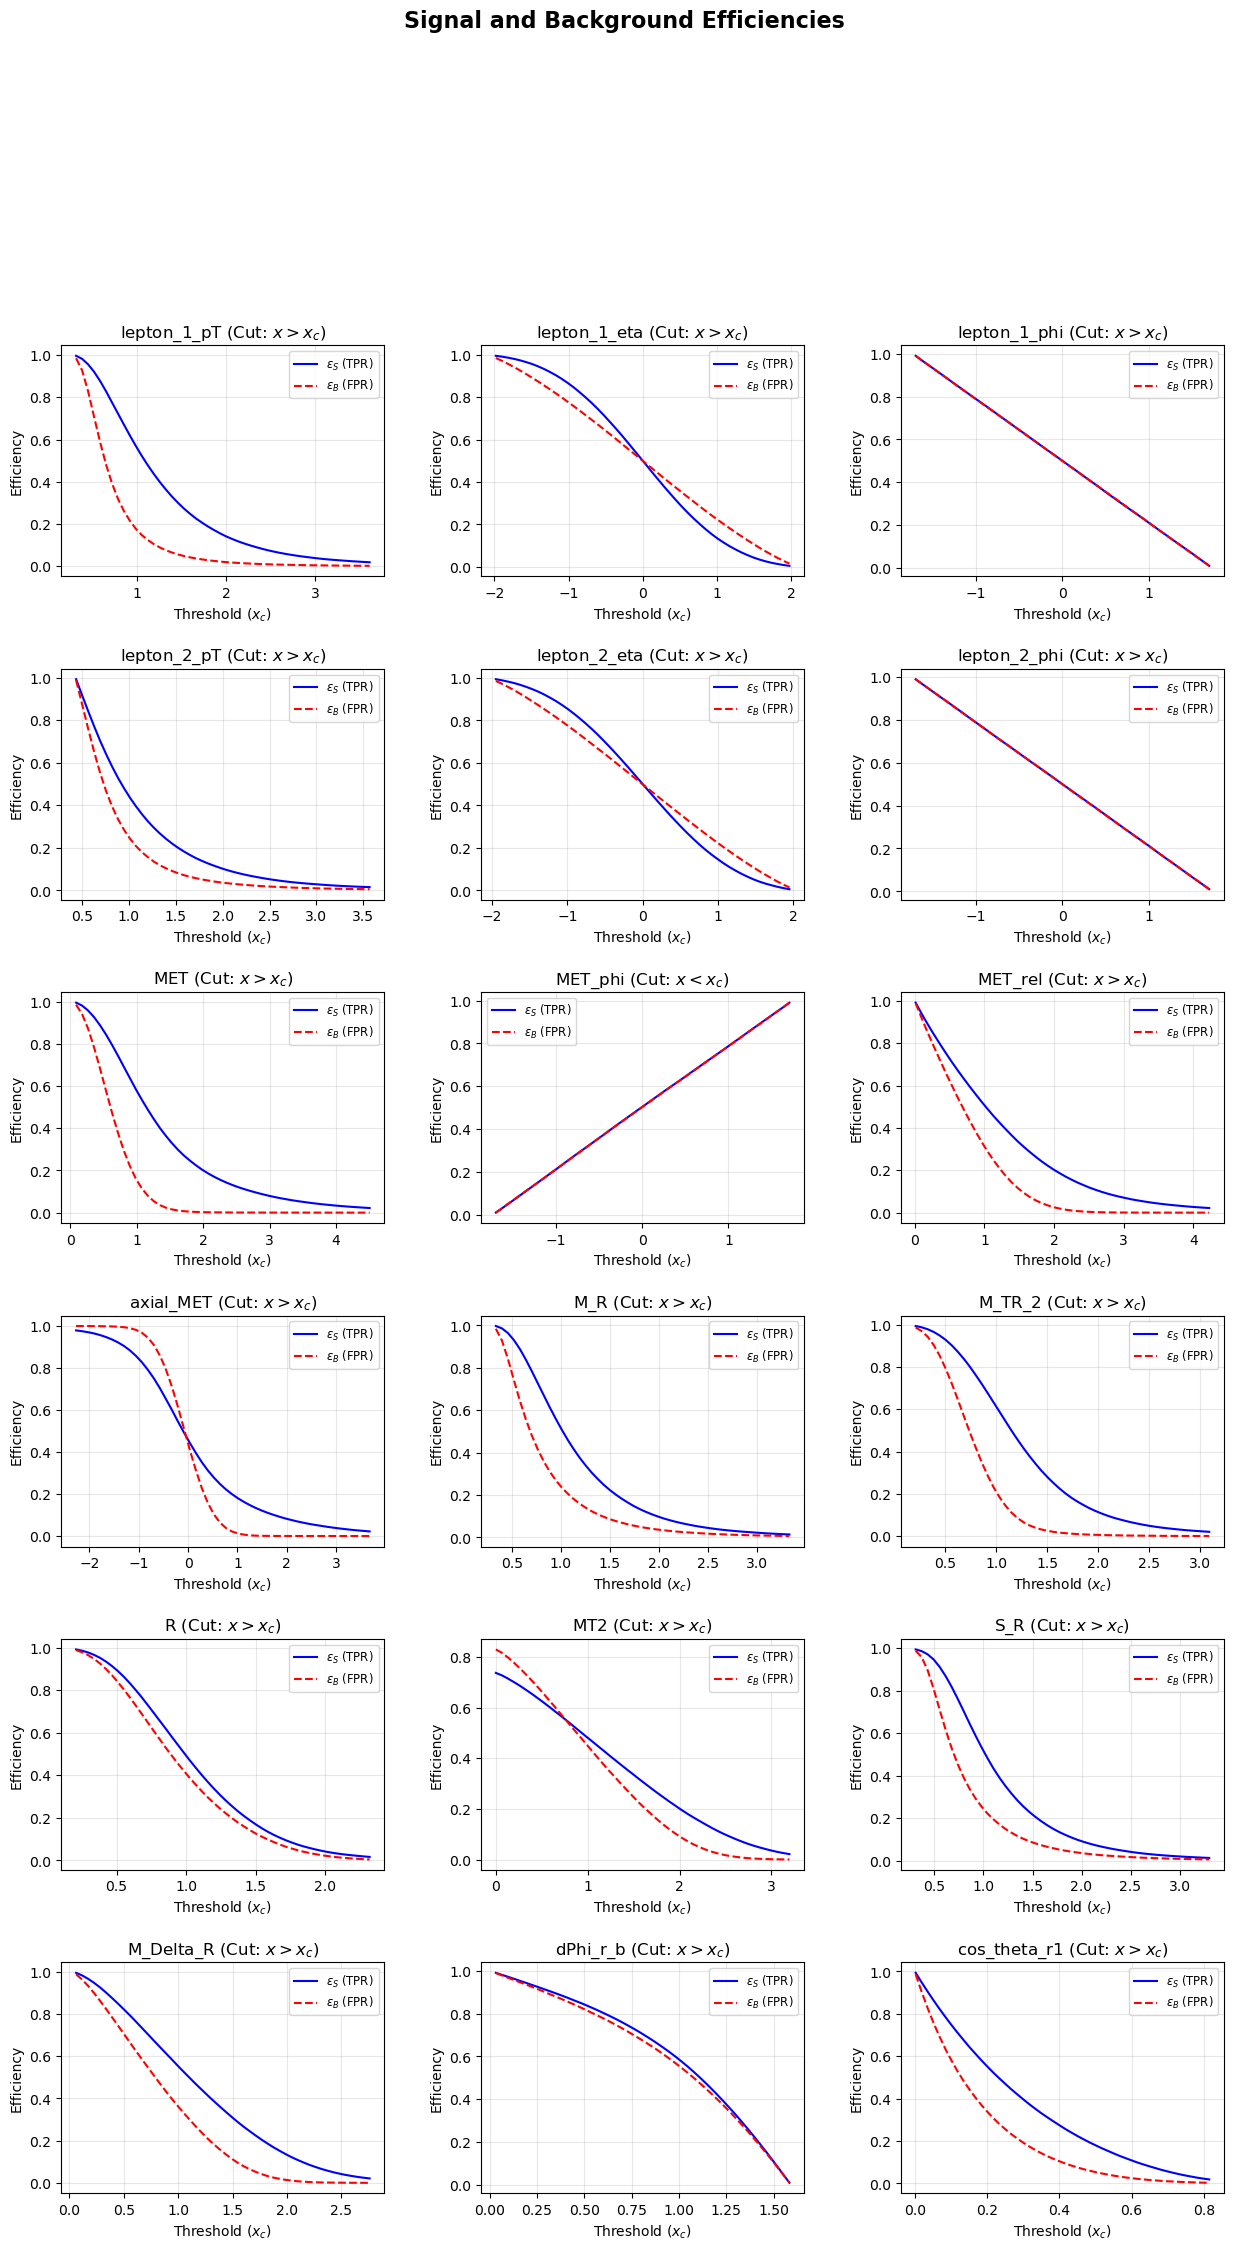

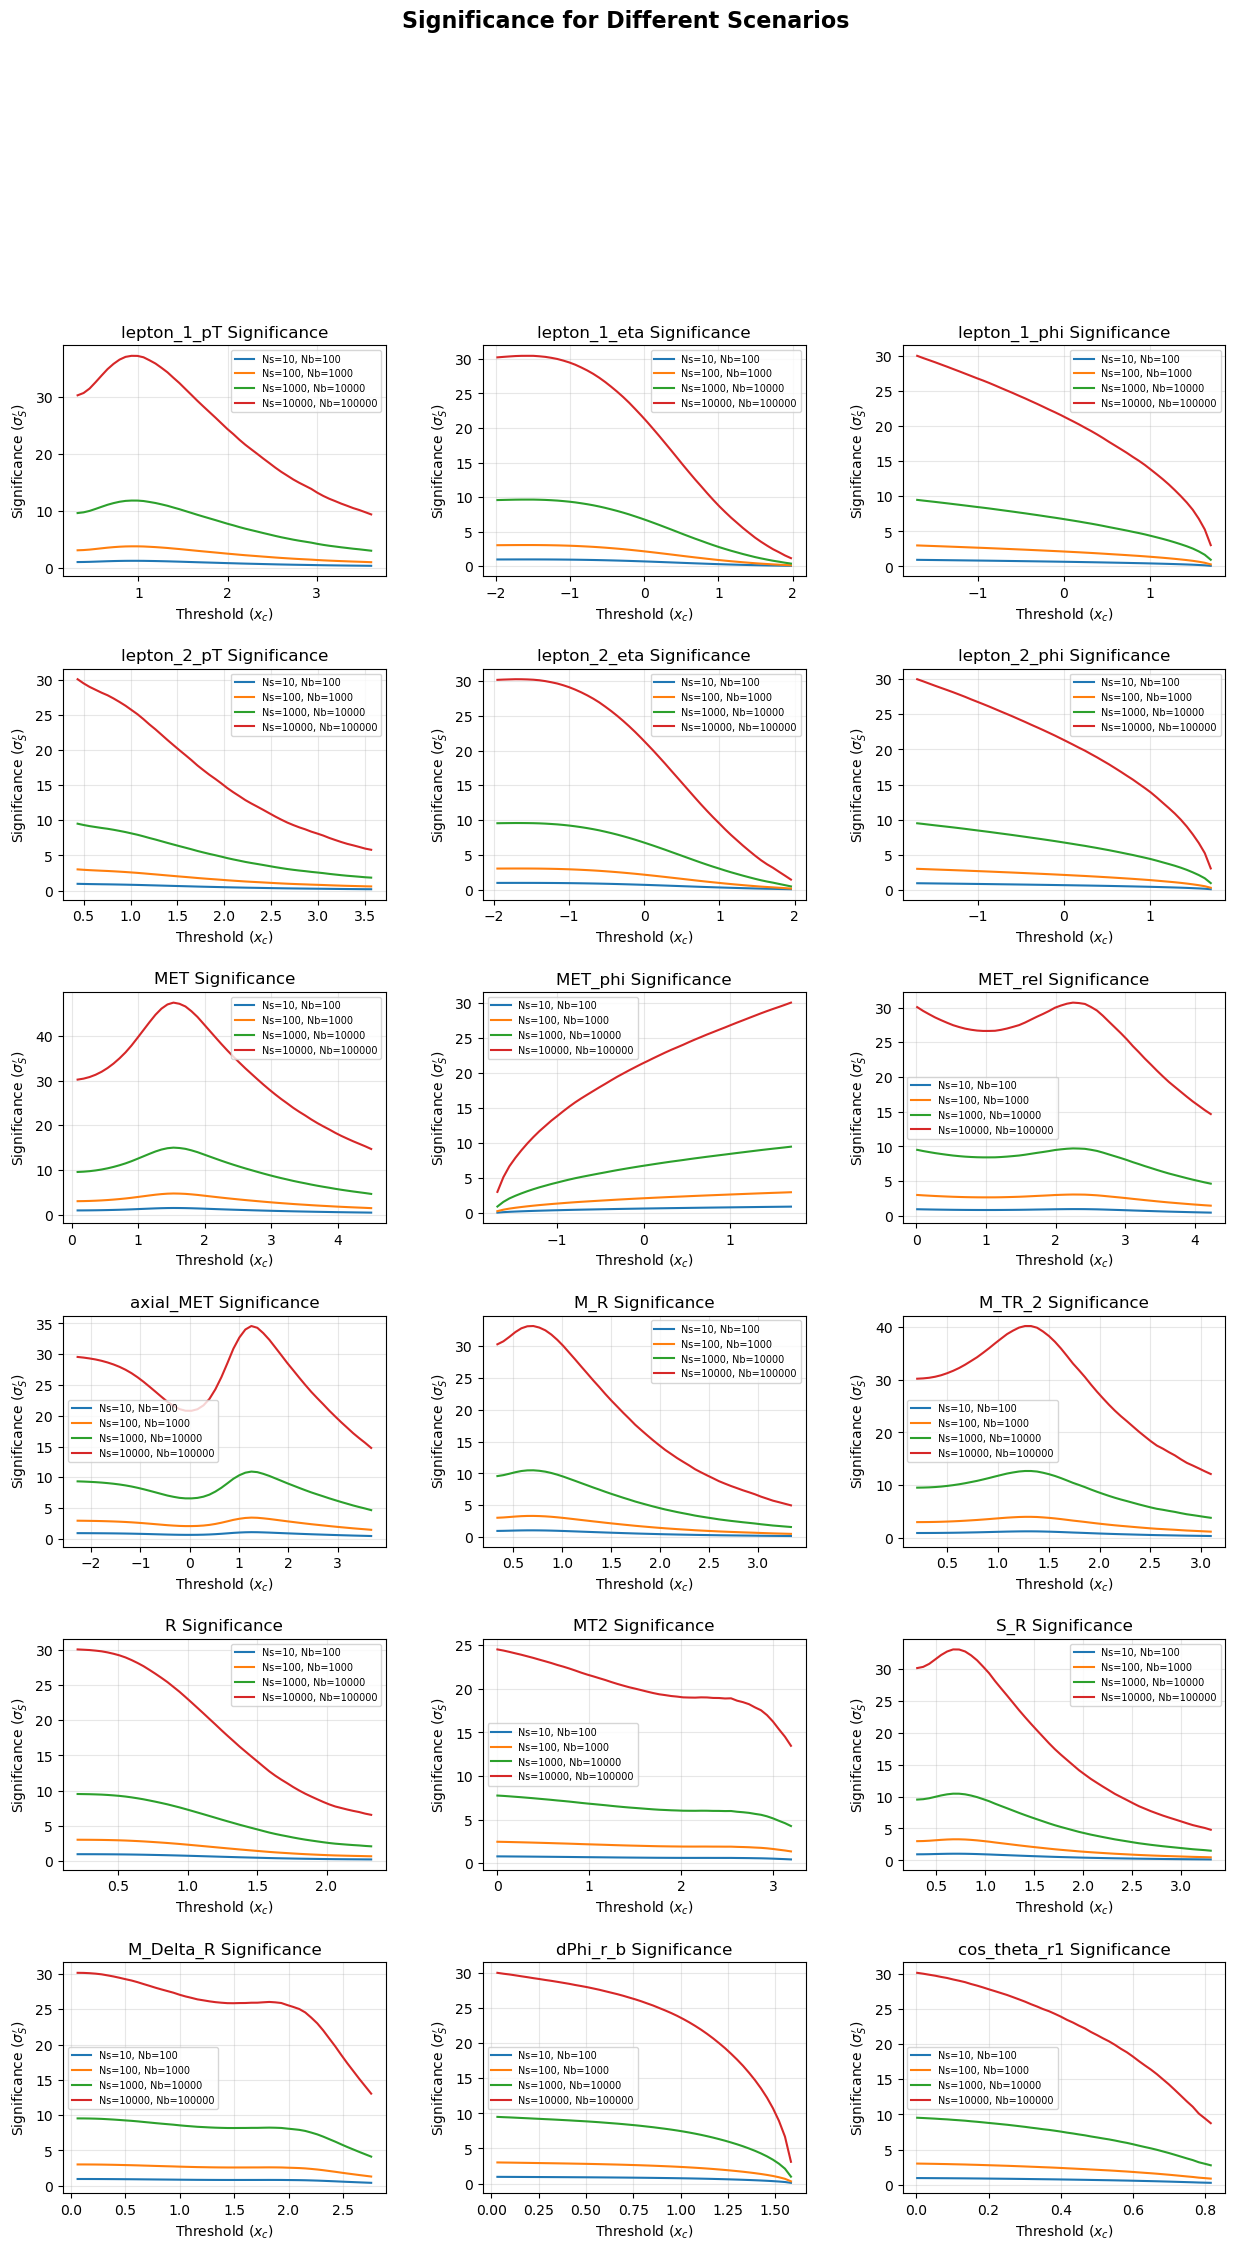

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math


all_features = [
    'lepton_1_pT', 'lepton_1_eta', 'lepton_1_phi', 
    'lepton_2_pT', 'lepton_2_eta', 'lepton_2_phi', 
    'MET', 'MET_phi', 
    'MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 
    'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1'
]

# Given scenarios defined
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

def calculate_efficiencies(sig_data, bkg_data, thresholds, cut_dir):
    tpr, fpr = [], []
    n_sig = len(sig_data)
    n_bkg = len(bkg_data)
    
    for xc in thresholds:
        if cut_dir == '>':
            tpr.append(np.sum(sig_data > xc) / n_sig)
            fpr.append(np.sum(bkg_data > xc) / n_bkg)
        else:
            tpr.append(np.sum(sig_data < xc) / n_sig)
            fpr.append(np.sum(bkg_data < xc) / n_bkg)
            
    return np.array(tpr), np.array(fpr)

def plot_selection_metrics(features):
    n_feats = len(features)
    n_cols = 3
    n_rows = math.ceil(n_feats / n_cols)
    
# Part 5.2 
    fig_eff, axes_eff = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    fig_eff.subplots_adjust(hspace=0.4, wspace=0.3)
    axes_eff = axes_eff.flatten()
    
# Part 5.3
    fig_sig, axes_sig = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    fig_sig.subplots_adjust(hspace=0.4, wspace=0.3)
    axes_sig = axes_sig.flatten()

    for i, feat in enumerate(features):
        sig_data = signal[feat].values
        bkg_data = background[feat].values
        
        # Auto-detect the best cut direction
        cut_dir = '>' if np.mean(sig_data) > np.mean(bkg_data) else '<'
        
        # Define 50 thresholds between the 1st and 99th percentile of the data
        min_val = np.percentile(df[feat], 1)
        max_val = np.percentile(df[feat], 99)
        thresholds = np.linspace(min_val, max_val, 50)
        
        # Get Efficiencies
        eps_S, eps_B = calculate_efficiencies(sig_data, bkg_data, thresholds, cut_dir)
        
        # Plot 5.2 (Efficiencies) 
        ax_e = axes_eff[i]
        ax_e.plot(thresholds, eps_S, label=r'$\epsilon_S$ (TPR)', color='blue')
        ax_e.plot(thresholds, eps_B, label=r'$\epsilon_B$ (FPR)', color='red', linestyle='--')
        ax_e.set_title(f"{feat} (Cut: $x {cut_dir} x_c$)")
        ax_e.set_xlabel(r'Threshold ($x_c$)')
        ax_e.set_ylabel('Efficiency')
        ax_e.legend(fontsize='small')
        ax_e.grid(alpha=0.3)
        
        # Plot 5.3 (Significance)
        ax_s = axes_sig[i]
        for (N_S, N_B) in scenarios:
            # Calculate N' for signal and background
            N_S_prime = eps_S * N_S
            N_B_prime = eps_B * N_B
            
            # Avoid division by zero
            denominator = np.sqrt(N_S_prime + N_B_prime)
            significance = np.divide(N_S_prime, denominator, out=np.zeros_like(N_S_prime), where=denominator!=0)
            
            ax_s.plot(thresholds, significance, label=f'Ns={N_S}, Nb={N_B}')
            
        ax_s.set_title(f"{feat} Significance")
        ax_s.set_xlabel(r'Threshold ($x_c$)')
        ax_s.set_ylabel(r'Significance ($\sigma_S^\prime$)')
        ax_s.legend(fontsize='x-small')
        ax_s.grid(alpha=0.3)

    # Hide any unused subplots
    for j in range(i + 1, len(axes_eff)):
        axes_eff[j].set_visible(False)
        axes_sig[j].set_visible(False)

    # Display 5.2
    fig_eff.suptitle("Signal and Background Efficiencies", fontsize=16, y=1.02, fontweight='bold')
    display(fig_eff)
    plt.close(fig_eff)
    
    # Display 5.3
    fig_sig.suptitle("Significance for Different Scenarios", fontsize=16, y=1.02, fontweight='bold')
    display(fig_sig)
    plt.close(fig_sig)

plot_selection_metrics(all_features)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [25]:
import numpy as np
import pandas as pd
import tabulate
from IPython.display import HTML, display

# Ensure signal and background dataframes are defined
signal = df[df['label'] == 1.0]
background = df[df['label'] == 0.0]

# Scenarios
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

chosen_features = ['MET', 'M_R', 'MT2']

def get_optimal_xc(feat, N_S, N_B, current_sig_mask=None, current_bkg_mask=None):
    # If no mask is provided, use all events
    if current_sig_mask is None:
        current_sig_mask = np.ones(len(signal), dtype=bool)
    if current_bkg_mask is None:
        current_bkg_mask = np.ones(len(background), dtype=bool)
        
    sig_data = signal[feat].values[current_sig_mask]
    bkg_data = background[feat].values[current_bkg_mask]
    
    # Auto-detect cut direction
    cut_dir = '>' if np.mean(signal[feat]) > np.mean(background[feat]) else '<'
    
    thresholds = np.linspace(np.percentile(df[feat], 1), np.percentile(df[feat], 99), 100)
    best_sig = 0
    best_xc = thresholds[0]
    
    for xc in thresholds:
        if cut_dir == '>':
            eps_S = np.sum(sig_data > xc) / len(signal) # Efficiency relative to total initial
            eps_B = np.sum(bkg_data > xc) / len(background)
        else:
            eps_S = np.sum(sig_data < xc) / len(signal)
            eps_B = np.sum(bkg_data < xc) / len(background)
            
        N_S_prime = eps_S * N_S
        N_B_prime = eps_B * N_B
        
        denominator = np.sqrt(N_S_prime + N_B_prime)
        if denominator > 0:
            sig_val = N_S_prime / denominator
            if sig_val > best_sig:
                best_sig = sig_val
                best_xc = xc
                
    return best_xc, cut_dir

# Part 6.1 & 6.2
display(HTML("<h2>Cut Flow Tables</h2>"))

# Store independent optimal cuts for part 6.3
independent_optimal_cuts = {}

for N_S, N_B in scenarios:
    display(HTML(f"<h3>Scenario: N_S = {N_S}, N_B = {N_B}</h3>"))
    
    table_data = []
    
    table_data.append(["Initial", "-", 1.0, 1.0, N_S, N_B, N_S / np.sqrt(N_S + N_B)])
    
    # Masks to keep track of surviving events
    surviving_sig = np.ones(len(signal), dtype=bool)
    surviving_bkg = np.ones(len(background), dtype=bool)
    
    independent_optimal_cuts[(N_S, N_B)] = {}
    
    for i, feat in enumerate(chosen_features):
        # Part 6.1: Find optimal x_c assuming NO prior cuts
        xc, cut_dir = get_optimal_xc(feat, N_S, N_B)
        independent_optimal_cuts[(N_S, N_B)][feat] = (xc, cut_dir)
        
        # Part 6.2: Apply cuts sequentially (Cut Flow)
        if cut_dir == '>':
            surviving_sig = surviving_sig & (signal[feat].values > xc)
            surviving_bkg = surviving_bkg & (background[feat].values > xc)
        else:
            surviving_sig = surviving_sig & (signal[feat].values < xc)
            surviving_bkg = surviving_bkg & (background[feat].values < xc)
            
        eps_S = np.sum(surviving_sig) / len(signal)
        eps_B = np.sum(surviving_bkg) / len(background)
        N_S_prime = eps_S * N_S
        N_B_prime = eps_B * N_B
        
        denom = np.sqrt(N_S_prime + N_B_prime)
        significance = N_S_prime / denom if denom > 0 else 0
        
        cut_name = f"Cut {i+1}: {feat} {cut_dir} {xc:.3f}"
        table_data.append([
            cut_name, 
            f"{feat} {cut_dir} {xc:.3f}", 
            f"{eps_S:.4f}", 
            f"{eps_B:.4f}", 
            f"{N_S_prime:.1f}", 
            f"{N_B_prime:.1f}", 
            f"{significance:.3f}"
        ])
        
    headers = ["Cut Level", "Selection", "eps_S", "eps_B", "N'_S", "N'_B", "Significance"]
    display(HTML(tabulate.tabulate(table_data, tablefmt='html', headers=headers)))


# Part 6.3: Addressing Correlation and Re-optimization
display(HTML("<h2>Correlation and Re-optimization</h2>"))

N_S_test, N_B_test = 1000, 10000
feat1, feat2 = 'MET', 'M_R'

#  Get independent optimal cuts from part 6.1
xc1_indep, dir1 = independent_optimal_cuts[(N_S_test, N_B_test)][feat1]
xc2_indep, dir2 = independent_optimal_cuts[(N_S_test, N_B_test)][feat2]

# Method A: Cut on Feat1 first, then optimize Feat2 on surviving events
sig_mask_A = (signal[feat1].values > xc1_indep)
bkg_mask_A = (background[feat1].values > xc1_indep)
xc2_reopt, _ = get_optimal_xc(feat2, N_S_test, N_B_test, current_sig_mask=sig_mask_A, current_bkg_mask=bkg_mask_A)

# Method B: Cut on Feat2 first, then optimize Feat1 on surviving events
sig_mask_B = (signal[feat2].values > xc2_indep)
bkg_mask_B = (background[feat2].values > xc2_indep)
xc1_reopt, _ = get_optimal_xc(feat1, N_S_test, N_B_test, current_sig_mask=sig_mask_B, current_bkg_mask=bkg_mask_B)

print(f"Independent Optima: {feat1} > {xc1_indep:.3f}, {feat2} > {xc2_indep:.3f}\n")

print(f"Method A")
print(f"  1. Apply {feat1} > {xc1_indep:.3f}")
print(f"  2. NEW optimal {feat2} threshold is now: {feat2} > {xc2_reopt:.3f}")

print(f"Method B")
print(f"  1. Apply {feat2} > {xc2_indep:.3f}")
print(f"  2. NEW optimal {feat1} threshold is now: {feat1} > {xc1_reopt:.3f}")

Cut Level,Selection,eps_S,eps_B,N'_S,N'_B,Significance
Initial,-,1,1,10,100,0.953463
Cut 1: MET > 1.559,MET > 1.559,0.3187,0.0134,3.2,1.3,1.498
Cut 2: M_R > 0.670,M_R > 0.670,0.2743,0.0095,2.7,1,1.427
Cut 3: MT2 > 0.000,MT2 > 0.000,0.178,0.0086,1.8,0.9,1.096


Cut Level,Selection,eps_S,eps_B,N'_S,N'_B,Significance
Initial,-,1,1,100,1000,3.01511
Cut 1: MET > 1.559,MET > 1.559,0.3187,0.0134,31.9,13.4,4.738
Cut 2: M_R > 0.670,M_R > 0.670,0.2743,0.0095,27.4,9.5,4.512
Cut 3: MT2 > 0.000,MT2 > 0.000,0.178,0.0086,17.8,8.6,3.466


Cut Level,Selection,eps_S,eps_B,N'_S,N'_B,Significance
Initial,-,1,1,1000,10000,9.53463
Cut 1: MET > 1.559,MET > 1.559,0.3187,0.0134,318.7,133.7,14.983
Cut 2: M_R > 0.670,M_R > 0.670,0.2743,0.0095,274.3,95.3,14.268
Cut 3: MT2 > 0.000,MT2 > 0.000,0.178,0.0086,178,85.6,10.962


Cut Level,Selection,eps_S,eps_B,N'_S,N'_B,Significance
Initial,-,1,1,10000,100000,30.1511
Cut 1: MET > 1.559,MET > 1.559,0.3187,0.0134,3186.5,1336.6,47.38
Cut 2: M_R > 0.670,M_R > 0.670,0.2743,0.0095,2743,952.9,45.12
Cut 3: MT2 > 0.000,MT2 > 0.000,0.178,0.0086,1779.8,856.5,34.664


Independent Optima: MET > 1.559, M_R > 0.670

Method A
  1. Apply MET > 1.559
  2. NEW optimal M_R threshold is now: M_R > 0.337
Method B
  1. Apply M_R > 0.670
  2. NEW optimal MET threshold is now: MET > 1.425


## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



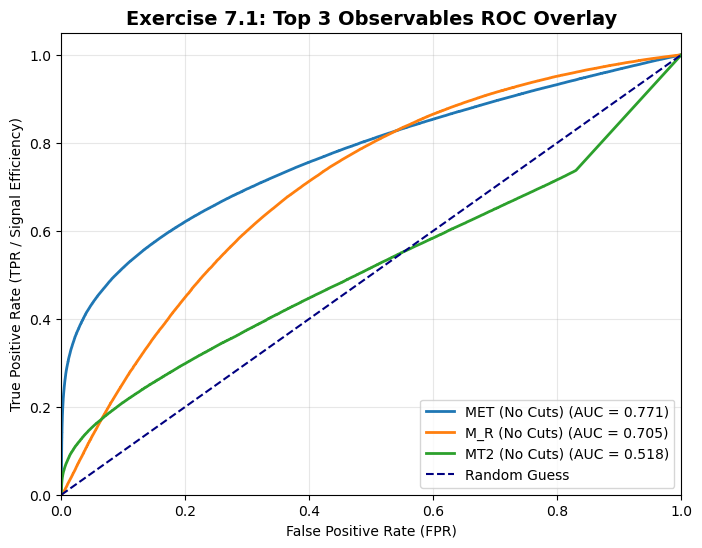

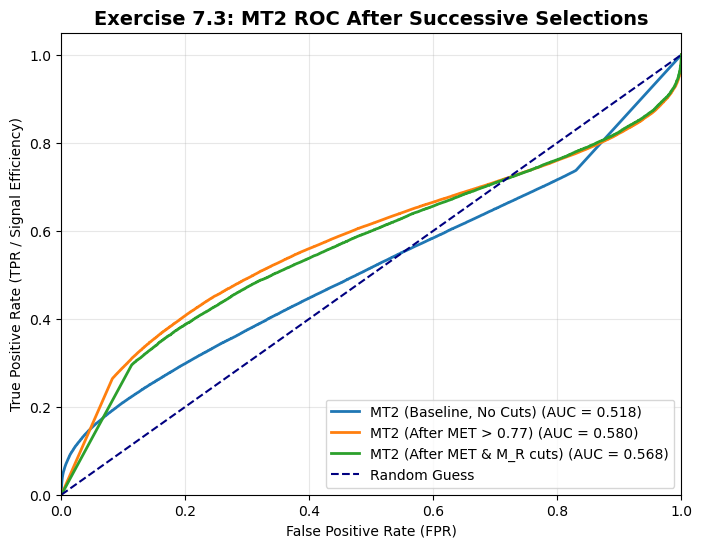

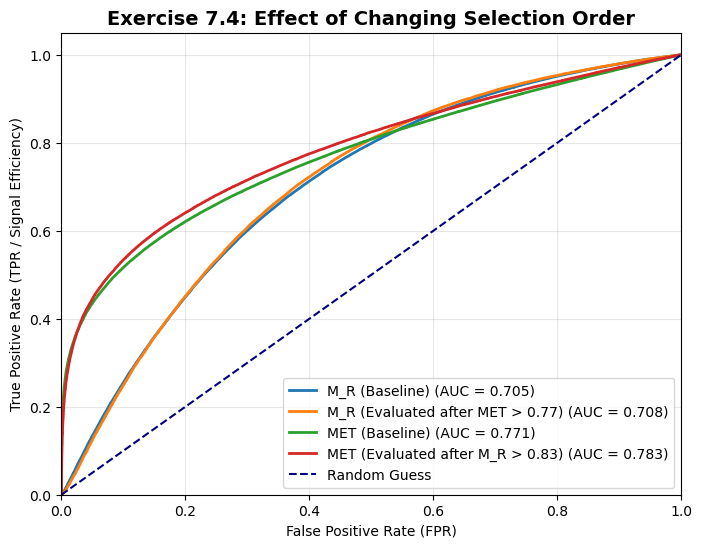

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# Part 7.2: Reusable Function for ROC Curves
def plot_roc_curves(roc_configs, title="ROC Curves"):
    # Creates an overlay of ROC curves.
   
    plt.figure(figsize=(8, 6))
    
    for df_subset, feat, label in roc_configs:
        y_true = df_subset['label'].values
        y_score = df_subset[feat].values
        
        if np.mean(y_score[y_true == 1]) < np.mean(y_score[y_true == 0]):
            y_score = -y_score
            
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {roc_auc:.3f})")
        
    # Plot the random guessing baseline
    plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR / Signal Efficiency)')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Part 7.1: Top 3 Observables ROC Overlay
# Use the top 3 discriminators identified previously
top_3_features = ['MET', 'M_R', 'MT2']

# Create the configuration list for our function
ex71_configs = [
    (df, 'MET', 'MET (No Cuts)'),
    (df, 'M_R', 'M_R (No Cuts)'),
    (df, 'MT2', 'MT2 (No Cuts)')
]

plot_roc_curves(ex71_configs, title="Exercise 7.1: Top 3 Observables ROC Overlay")


# Part 7.3: ROC Curves for Successive Selections

# Define arbitrary but sensible cuts (e.g., above the 50th percentile)
cut_MET = np.percentile(df['MET'], 50)
cut_MR = np.percentile(df['M_R'], 50)

# Create successive subsets of the data
df_cut1 = df[df['MET'] > cut_MET]
df_cut2 = df_cut1[df_cut1['M_R'] > cut_MR]

ex73_configs = [
    (df,      'MT2', 'MT2 (Baseline, No Cuts)'),
    (df_cut1, 'MT2', f'MT2 (After MET > {cut_MET:.2f})'),
    (df_cut2, 'MT2', f'MT2 (After MET & M_R cuts)')
]

plot_roc_curves(ex73_configs, title="Exercise 7.3: MT2 ROC After Successive Selections")


# Part 7.4: Effect of Changing Selection Order

# Subset A: Cut on MET, evaluate M_R
df_cut_MET = df[df['MET'] > cut_MET]

# Subset B: Cut on M_R, evaluate MET
df_cut_MR = df[df['M_R'] > cut_MR]

ex74_configs = [
    (df,         'M_R', 'M_R (Baseline)'),
    (df_cut_MET, 'M_R', f'M_R (Evaluated after MET > {cut_MET:.2f})'),
    (df,         'MET', 'MET (Baseline)'),
    (df_cut_MR,  'MET', f'MET (Evaluated after M_R > {cut_MR:.2f})')
]

plot_roc_curves(ex74_configs, title="Exercise 7.4: Effect of Changing Selection Order")